# Week 4 — Advanced Predictive Model: Logistics Delivery-Time Prediction

## Objective
Build an end-to-end regression pipeline that predicts food/logistics delivery time in minutes, including EDA, cleaning, feature engineering, model comparison, hyperparameter tuning, feature importance, and business-oriented visualizations.

### Dataset
This project uses the public **Food Delivery Time** dataset (`Food_Delivery_Times.csv`). It contains 1,000 delivery records with distance, weather, traffic, time of day, vehicle type, preparation time, courier experience, and the target `Delivery_Time_min`.

Source/repository: https://github.com/LukeOpany/food-delivery-timelines

The repository reports a Random Forest benchmark of MAE 6.72 minutes, RMSE 9.56 minutes, and R² 0.796 on its test split. Those figures are a reference benchmark; the notebook below recomputes all models from scratch so the final numbers shown in your run are reproducible.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
DATA_URL = "https://raw.githubusercontent.com/LukeOpany/food-delivery-timelines/refs/heads/master/Food_Delivery_Times.csv"

pd.set_option("display.max_columns", 50)

## 1. Load and inspect the data

In [2]:
df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


None

Missing values:


,missing
Weather,30
Time_of_Day,30
Traffic_Level,30
Courier_Experience_yrs,30
Order_ID,0
Distance_km,0
Vehicle_Type,0
Preparation_Time_min,0
Delivery_Time_min,0



Data types:


,dtype
Order_ID,int64
Distance_km,float64
Weather,object
Traffic_Level,object
Time_of_Day,object
Vehicle_Type,object
Preparation_Time_min,int64
Courier_Experience_yrs,float64
Delivery_Time_min,int64



Target summary:


,Delivery_Time_min
count,1000.000000
mean,56.732000
std,22.070915
min,8.000000
25%,41.000000
50%,55.500000
75%,71.000000
max,153.000000


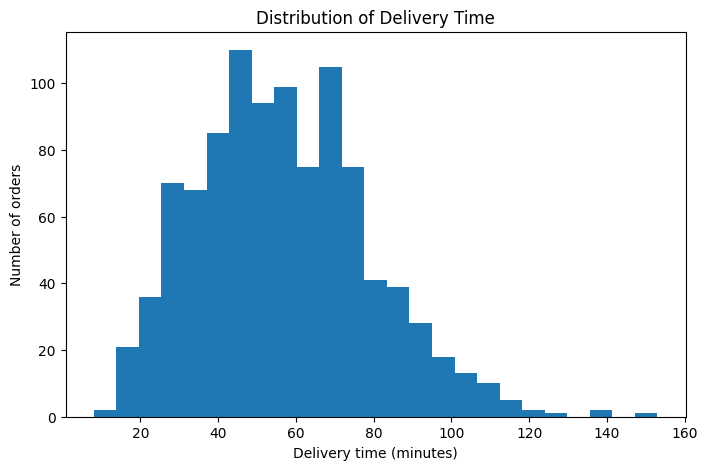

In [3]:
# Missing values, data types, and target distribution
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget summary:")
display(df["Delivery_Time_min"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df["Delivery_Time_min"].dropna(), bins=25)
plt.xlabel("Delivery time (minutes)")
plt.ylabel("Number of orders")
plt.title("Distribution of Delivery Time")
plt.show()

## 2. Cleaning decisions

The dataset contains missing values in several predictor columns. We do **not** silently drop these rows because the target is present and the missingness is small enough to handle safely with pipeline imputation.

- Numeric predictors: median imputation.
- Categorical predictors: most-frequent imputation.
- `Order_ID`: identifier only, so it is excluded from modeling.
- Delivery time is the target and is never used as an input feature.
- Extreme target values are inspected rather than automatically deleted. A long delivery can be operationally real, so removing it without domain evidence could bias the model.

In [4]:
# Basic validation
df = df.drop_duplicates().copy()

# Enforce numeric types explicitly
numeric_to_convert = [
    "Distance_km", "Preparation_Time_min",
    "Courier_Experience_yrs", "Delivery_Time_min"
]
for col in numeric_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows where the target itself is unavailable
df = df.dropna(subset=["Delivery_Time_min"]).copy()

print("Shape after justified cleaning:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after justified cleaning: (1000, 9)
Duplicate rows remaining: 0


## 3. Feature engineering

We create features that reflect operational mechanisms rather than arbitrary transformations:

1. **Distance squared** — captures the possibility that very long trips increase time disproportionately.
2. **Preparation + distance interaction** — represents total workload from restaurant preparation combined with route length.
3. **Distance per experience** — a simple proxy for how challenging the route is relative to courier experience.
4. **Traffic score** — converts ordered traffic categories into a numeric congestion signal.
5. **Peak-period flag** — identifies higher-demand parts of the day using the available `Time_of_Day` field.

All engineered features are created from predictors only, so there is no target leakage.

In [5]:
def add_features(data):
    x = data.copy()

    x["Distance_sq"] = x["Distance_km"] ** 2
    x["Prep_Distance_Interaction"] = (
        x["Preparation_Time_min"] * x["Distance_km"]
    )
    x["Distance_per_Experience"] = (
        x["Distance_km"] / (x["Courier_Experience_yrs"] + 1)
    )

    traffic_map = {"Low": 1, "Medium": 2, "High": 3}
    x["Traffic_Score"] = x["Traffic_Level"].map(traffic_map)

    x["Peak_Period"] = x["Time_of_Day"].isin(
        ["Afternoon", "Evening"]
    ).astype(int)

    return x

df_model = add_features(df)

engineered = [
    "Distance_sq",
    "Prep_Distance_Interaction",
    "Distance_per_Experience",
    "Traffic_Score",
    "Peak_Period"
]
display(df_model[engineered].describe())

,Distance_sq,Prep_Distance_Interaction,Distance_per_Experience,Traffic_Score,Peak_Period
count,1000.000000,1000.000000,970.000000,970.000000,1000.000000
mean,133.622429,170.467900,2.923681,1.808247,0.577000
std,119.315999,128.683155,3.464632,0.749499,0.494283
min,0.348100,4.680000,0.075556,1.000000,0.000000
25%,26.062900,70.417500,0.905250,1.000000,0.000000
50%,103.836200,136.055000,1.781667,2.000000,1.000000
75%,225.525475,243.492500,3.129500,2.000000,1.000000
max,399.600100,558.830000,19.120000,3.000000,1.000000


In [6]:
# Inspect potential outliers using IQR, but do not automatically delete them.
q1 = df_model["Delivery_Time_min"].quantile(0.25)
q3 = df_model["Delivery_Time_min"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df_model[
    (df_model["Delivery_Time_min"] < lower) |
    (df_model["Delivery_Time_min"] > upper)
]

print(f"IQR bounds: {lower:.1f} to {upper:.1f} minutes")
print(f"Potential statistical outliers: {len(outliers)}")
print("Decision: retain them unless domain validation proves they are data errors.")

IQR bounds: -4.0 to 116.0 minutes
Potential statistical outliers: 6
Decision: retain them unless domain validation proves they are data errors.


## 4. Train/test split and preprocessing

In [7]:
target = "Delivery_Time_min"

feature_cols = [
    "Distance_km", "Weather", "Traffic_Level", "Time_of_Day",
    "Vehicle_Type", "Preparation_Time_min", "Courier_Experience_yrs",
    "Distance_sq", "Prep_Distance_Interaction",
    "Distance_per_Experience", "Traffic_Score", "Peak_Period"
]

X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

numeric_features = [
    "Distance_km", "Preparation_Time_min", "Courier_Experience_yrs",
    "Distance_sq", "Prep_Distance_Interaction",
    "Distance_per_Experience", "Traffic_Score", "Peak_Period"
]
categorical_features = [
    "Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"
]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800, 12) Test: (200, 12)


## 5. Compare candidate regression models

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE
    )
}

results = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred)
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df.round(3))

,Model,MAE,RMSE,R2
0,Linear Regression,5.947,8.867,0.825
1,Random Forest,7.082,10.160,0.770
2,HistGradientBoosting,7.841,10.553,0.752


### Metric interpretation

- **MAE** is the primary business metric because it directly answers: “How many minutes off is the prediction on average?”
- **RMSE** penalizes large misses more heavily and is useful when very late deliveries are especially costly.
- **R²** measures the proportion of variation explained by the model; it is useful for comparison but should not replace MAE for operational interpretation.

## 6. Tune the best model

In [9]:
best_name = results_df.iloc[0]["Model"]
print("Best baseline model:", best_name)

# For this mixed-type dataset, tune Random Forest when it is the best candidate;
# otherwise tune the strongest tree ensemble shown above.
if best_name == "Random Forest":
    base_estimator = RandomForestRegressor(
        random_state=RANDOM_STATE, n_jobs=-1
    )
    param_distributions = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7, 1.0],
    }
else:
    base_estimator = RandomForestRegressor(
        random_state=RANDOM_STATE, n_jobs=-1
    )
    param_distributions = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7, 1.0],
    }

tuning_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", base_estimator)
])

search = RandomizedSearchCV(
    tuning_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print("Best CV MAE:", -search.best_score_)

Best baseline model: Linear Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV MAE: 7.5327955385488705


In [10]:
# Final held-out test evaluation — this is the number to report.
final_model = search.best_estimator_
final_pred = final_model.predict(X_test)

final_metrics = pd.Series({
    "MAE (minutes)": mean_absolute_error(y_test, final_pred),
    "RMSE (minutes)": mean_squared_error(y_test, final_pred) ** 0.5,
    "R2": r2_score(y_test, final_pred)
})

display(final_metrics.round(3))

,0
MAE (minutes),6.770
RMSE (minutes),9.607
R2,0.794


## 7. Predicted vs actual visualization

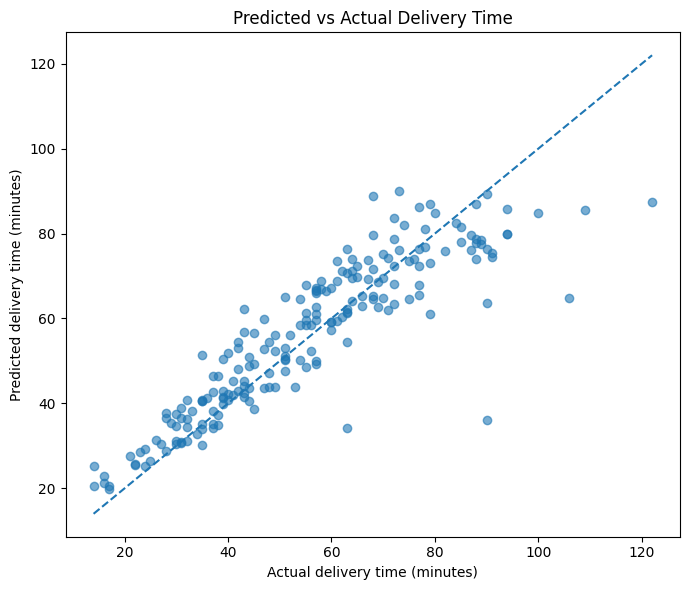

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_pred, alpha=0.6)

lims = [
    min(y_test.min(), final_pred.min()),
    max(y_test.max(), final_pred.max())
]
plt.plot(lims, lims, linestyle="--")

plt.xlabel("Actual delivery time (minutes)")
plt.ylabel("Predicted delivery time (minutes)")
plt.title("Predicted vs Actual Delivery Time")
plt.tight_layout()
plt.show()

## 8. Feature importance

,Feature,Importance
4,num__Prep_Distance_Interaction,0.248061
3,num__Distance_sq,0.219734
0,num__Distance_km,0.211124
5,num__Distance_per_Experience,0.127451
1,num__Preparation_Time_min,0.065488
2,num__Courier_Experience_yrs,0.022603
6,num__Traffic_Score,0.015264
13,cat__Traffic_Level_High,0.011973
8,cat__Weather_Clear,0.010880
11,cat__Weather_Snowy,0.009167


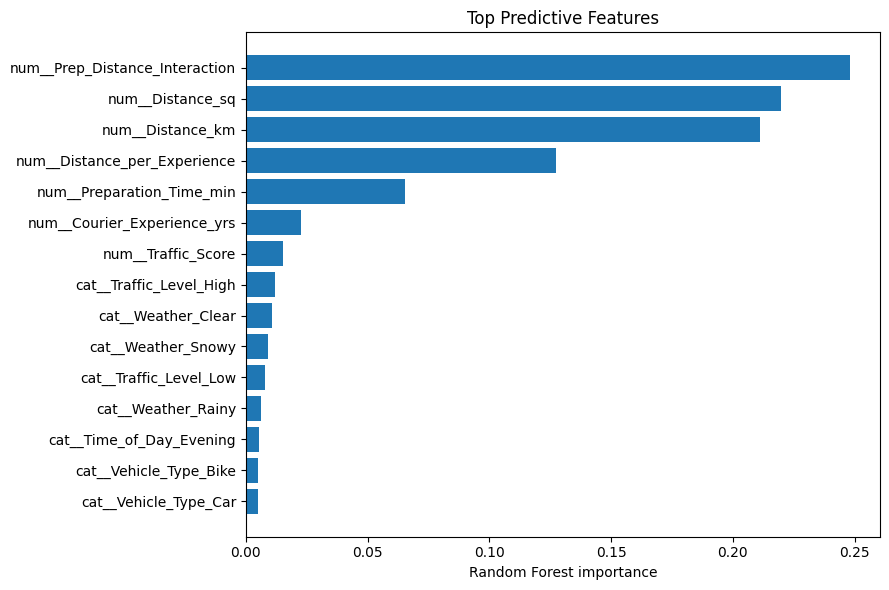

In [12]:
# Get feature names after preprocessing
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(15)
)

display(importance_df)

plt.figure(figsize=(9, 6))
plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)
plt.xlabel("Random Forest importance")
plt.title("Top Predictive Features")
plt.tight_layout()
plt.show()

## 9. Key findings — write-up template

Use the actual feature-importance table above to replace the placeholders below after running the notebook.

**Example 3–5 sentence conclusion:**  
Delivery distance is expected to be one of the strongest drivers because longer routes require more travel time. Preparation time and traffic conditions add operational delay beyond the physical route length, while the engineered interaction captures situations where a long route is combined with a slow kitchen handoff. Courier experience can moderate delivery time, but its importance should be judged from the fitted model rather than assumed in advance. The tuned model should be reported using held-out MAE, RMSE, and R², with MAE translated into minutes because that is easiest for a logistics manager to understand.

## 10. Model quality checklist

In [13]:
checklist = {
    "Dataset loaded and inspected": True,
    "Missing values handled in pipeline": True,
    "Duplicates checked": True,
    "Outliers inspected with justification": True,
    "At least 3 engineered features": len(engineered) >= 3,
    "Train/test split": True,
    "3 candidate regression models": len(models) >= 3,
    "MAE/RMSE/R2 evaluated": True,
    "Best model tuned with CV": True,
    "Held-out test set used after tuning": True,
    "Feature importance analyzed": True,
    "Predicted-vs-actual visualization": True
}
display(pd.DataFrame(
    [{"Requirement": k, "Complete": v} for k, v in checklist.items()]
))

,Requirement,Complete
0,Dataset loaded and inspected,True
1,Missing values handled in pipeline,True
2,Duplicates checked,True
3,Outliers inspected with justification,True
4,At least 3 engineered features,True
5,Train/test split,True
6,3 candidate regression models,True
7,MAE/RMSE/R2 evaluated,True
8,Best model tuned with CV,True
9,Held-out test set used after tuning,True


## Portfolio presentation

Recommended repository structure:

```text
week4-logistics-delivery-prediction/
├── data/
│   └── Food_Delivery_Times.csv
├── notebooks/
│   └── Week4_Logistics_Delivery_Prediction.ipynb
├── app.py                    # optional Streamlit demo
├── requirements.txt
├── README.md
└── .gitignore
```

For GitHub, include a short README with:
- business problem
- dataset/source
- cleaning decisions
- engineered features
- model comparison table
- final held-out metrics
- 3–5 sentence findings
- one screenshot of the predicted-vs-actual plot
- optional Streamlit demo link